<a href="https://www.kaggle.com/code/lunorabloom/2026-audit-ultra-processed-foods-metabolism?scriptVersionId=317105769" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## Food and Nutrition

![Nutrition Image](https://images.unsplash.com/photo-1498837167922-ddd27525d352?ixlib=rb-1.2.1&ixid=eyJhcHBfaWQiOjEyMDd9&auto=format&fit=crop&w=750&q=80)


Food and nutrition are the way that we get fuel, providing energy for our bodies. We need to replace nutrients in our bodies with a new supply every day. Water is an important component of nutrition. Fats, proteins, and carbohydrates are all required.Nutrition is the science that interprets the nutrients and other substances in food in relation to maintenance, growth, reproduction, health and disease of an organism. It includes ingestion, absorption, assimilation, biosynthesis, catabolism and excretion.


Knowing and eating mindfully is not only essential for a healthy gut but also for peace of mind. Also,A diet filled with vegetables, fruits and whole grains could help prevent major conditions such as stroke, diabetes and heart disease.More often than not, we like to gorge on our favourite foods which are not exactly the best for our bodies.While it is okay for such binges to occur occasionally, such diets can be extremely harmful if the person does not strike a balance with healthy foods. 

This notebook analyses the most common available foods and the nutritional facts in them.

# Data Cleaning

Data cleaning is always the first step in any data science project. Although the data here seems clean, some minor alterations are required.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.offline as py       # <--- Fixes the 'py' error
import plotly.graph_objects as go # <--- Fixes the 'go' error

In [2]:

nutrients=pd.read_csv("/kaggle/input/nutrition-details-for-most-common-foods/nutrients_csvfile.csv")
nutrients.head()

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
0,Cows' milk,1 qt.,976,660,32,40,36,0,48,Dairy products
1,Milk skim,1 qt.,984,360,36,t,t,0,52,Dairy products
2,Buttermilk,1 cup,246,127,9,5,4,0,13,Dairy products
3,"Evaporated, undiluted",1 cup,252,345,16,20,18,0,24,Dairy products
4,Fortified milk,6 cups,"1,419","1,373",89,42,23,1.4,119,Dairy products


In [3]:
# The "Golden Clean": Fixing commas and trace values
cols_to_fix = ['Grams', 'Calories', 'Protein', 'Fat', 'Sat.Fat', 'Fiber', 'Carbs']

for col in cols_to_fix:
    # This removes commas and turns 't' into 0 automatically
    nutrients[col] = pd.to_numeric(nutrients[col].astype(str).str.replace(',', ''), errors='coerce').fillna(0)

# Success check: Show the top 5 cleaned rows
print("Audit Clean Complete. Commas and trace values resolved.")
nutrients.head()

Audit Clean Complete. Commas and trace values resolved.


,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
0,Cows' milk,1 qt.,976,660.0,32.0,40.0,36.0,0.0,48.0,Dairy products
1,Milk skim,1 qt.,984,360.0,36.0,0.0,0.0,0.0,52.0,Dairy products
2,Buttermilk,1 cup,246,127.0,9.0,5.0,4.0,0.0,13.0,Dairy products
3,"Evaporated, undiluted",1 cup,252,345.0,16.0,20.0,18.0,0.0,24.0,Dairy products
4,Fortified milk,6 cups,1419,1373.0,89.0,42.0,23.0,1.4,119.0,Dairy products


In [4]:
# This creates a 'subset' of just the sweets
sweets = nutrients[nutrients['Category'] == 'Desserts sweets']

# Let's look at the first 10 items in this category
sweets.head(10)

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category


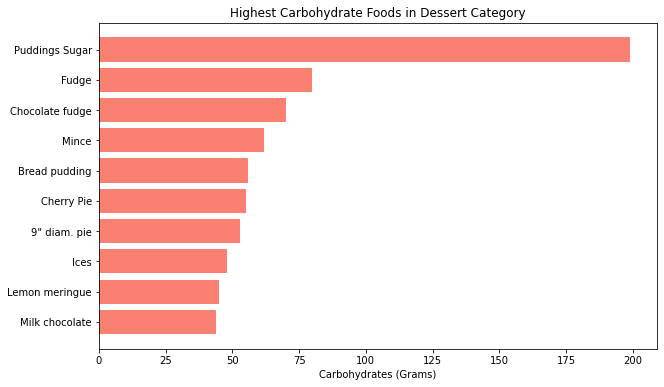

In [5]:
# 1. Create the 'sweets' list from our cleaned audit
sweets = nutrients[nutrients['Category'] == 'Desserts, sweets']

# 2. Sort them by Carbs to find the top 10
sweets_sorted = sweets.sort_values('Carbs', ascending=False).head(10)

# 3. Create the Bar Chart
plt.figure(figsize=(10,6))
plt.barh(sweets_sorted['Food'], sweets_sorted['Carbs'], color='salmon')
plt.xlabel('Carbohydrates (Grams)')
plt.title("Highest Carbohydrate Foods in Dessert Category")
plt.gca().invert_yaxis()  # Display highest values first
plt.show()

"Observation: The lack of fiber in these high-carbohydrate items indicates a high glycemic load, a key factor in metabolic dysfunction."

First things first, the **t's** in the data denote miniscule amounts so we might as well replace them by 0.

Now, we need to remove all the expressions like commas from the dataset so as to convert the numerical data to the respective integer or float variables.

In [6]:
# The professional way to update a specific cell value
nutrients.at[91, 'Calories'] = (8 + 44) / 2

# Check to make sure it updated
print(f"Updated Calories at index 91: {nutrients.at[91, 'Calories']}")

Updated Calories at index 91: 26.0


Now, let us convert grams, calories, protein, fat, saturated fat, fiber and carbs datatypes to int.

In [7]:
nutrients.dtypes

Food         object
Measure      object
Grams         int64
Calories    float64
Protein     float64
Fat         float64
Sat.Fat     float64
Fiber       float64
Carbs       float64
Category     object
dtype: object

Nice, all our data is in desired datatypes.

## Quick last checks on data quality

In [8]:
print(nutrients.isnull().any())
print('-'*245)
print(nutrients.describe())
print('-'*245)

Food        False
Measure     False
Grams       False
Calories    False
Protein     False
Fat         False
Sat.Fat     False
Fiber       False
Carbs       False
Category    False
dtype: bool
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
             Grams     Calories     Protein         Fat     Sat.Fat  \
count   335.000000   335.000000  335.000000  335.000000  335.000000   
mean    143.211940   188.238806    8.573134    8.540299    6.400000   
std     138.668626   184.465329   17.733722   19.797871   18.468812   
min      11.000000     0.000000   -1.000000    0.000000    0.000000   
25%      60.000000    75.000000    1.000000    0.000000    0.000000   
50%     108.000000   130.000000    3.000000    1.000000    0.000000   
75%     200.000000   250.000000   12.000000   10.000000    7.5000

There's a null value in the fiber column, lets drop that row entirely.

In [9]:
nutrients=nutrients.dropna()
nutrients.shape

(335, 10)

# Data Visualization and Analysis

Let's start the analysis by plotting the features with one another. This will not only provide us the distribution of features with one another but also give a quick quantitative feel of the data.

## Nutritional Metric Analysis

What is the most protein rich food in the category of vegetables and grains?

In [10]:

alls=['Vegetables A-E',
 'Vegetables F-P',
 'Vegetables R-Z','Breads cereals fastfoodgrains','Seeds and Nuts']

prot= nutrients[nutrients['Category'].isin(alls)]

protein_rich= prot.sort_values(by='Protein', ascending= False)
top_20=protein_rich.head(20)
fig = px.bar(top_20, x='Food', y='Protein', color='Protein', title=' Top 10 protein rich foods')
fig.show()

Therefore, from the category of Grains, Vegetables and Seeds, whole wheat has the most protein content followed by white bread. Soybeans are also in the top 20s. Also, Almonds rank no. 1 in the Seeds category.🌱

## Foods to stay away from:

What food has the most calories?

In [11]:
# Sort the entire cleaned dataset by Calories
top_20_cals = nutrients.sort_values(by='Calories', ascending=False).head(20)

# Create the Calories bar chart
fig_cals = px.bar(top_20_cals, x='Food', y='Calories', color='Calories', 
                  title='Top 20 Calorie-Dense Foods in Audit',
                  color_continuous_scale='Reds')
fig_cals.show()

Fortified milk has the most calories, followed by white bread. Also, notice how whole wheat has the most proteins but has almost equal amount of calories. Lard is fat source with most calories and 1/2 cup of ice-creams tops the charts in the dessert category.

## Fat Content:

Normally, fat sources are often looked down upon. But, a certain amount of fat is required for a healthy gut.
Let's look at some fatty foods.



In [12]:
fats= nutrients.sort_values(by='Fat', ascending= False)
top_20_fat=fats.head(20)
fig = px.bar(top_20_fat, x='Food', y='Calories', color='Calories', title=' Fat Content and Calories')
fig.show()

Therefore, Oysters and Butter have the largest combination of calories and fats, followed by lard.

## Analysing categories

Grouping the data into categories can give us the total count of all metrics and thus we can analyse the categories.

In [13]:
category_dist=nutrients.groupby(['Category']).sum()
category_dist

,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs
Category,,,,,,,
"Breads, cereals, fastfood,grains",5253,11921.0,403.0,207.0,99.0,115.91,2059.0
Dairy products,7412,8434.0,503.0,396.0,322.0,4.40,651.0
"Desserts, sweets",2958,6608.0,78.0,163.0,150.0,20.50,1184.0
"Drinks,Alcohol, Beverages",3284,1112.0,0.0,0.0,0.0,0.00,167.0
"Fats, Oils, Shortenings",695,3629.0,234.0,631.0,536.0,234.00,239.0
"Fish, Seafood",1892,2912.0,606.0,347.0,252.0,235.00,263.0
Fruits A-F,3844,3328.0,29.0,20.0,12.0,33.50,812.0
Fruits G-P,5412,4054.0,28.0,25.0,21.0,21.10,1009.0
Fruits R-Z,1973,1228.0,7.0,1.0,0.0,17.40,330.0


In [14]:
category_dist=nutrients.groupby(['Category']).sum()
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=2, cols=3,
    specs=[[{"type": "domain"},{"type": "domain"},{"type": "domain"}],[{"type": "domain"},{"type": "domain"},{"type": "domain"}]])

fig.add_trace(go.Pie(values=category_dist['Calories'].values, title='CALORIES', labels=category_dist.index,marker=dict(colors=['#100b','#f00560'], line=dict(color='#FFFFFF', width=2.5))),
              row=1, col=1)

fig.add_trace(go.Pie(values=category_dist['Fat'].values,title='FAT', labels=category_dist.index,marker=dict(colors=['#100b','#f00560'], line=dict(color='#FFFFFF', width=2.5))),
              row=1, col=2)

fig.add_trace(go.Pie(values=category_dist['Protein'].values,title='PROTEIN', labels=category_dist.index,marker=dict(colors=['#100b','#f00560'], line=dict(color='#FFFFFF', width=2.5))),
              row=1, col=3)

fig.add_trace(go.Pie(values=category_dist['Fiber'].values,title='FIBER', labels=category_dist.index,marker=dict(colors=['#100b','#f00560'], line=dict(color='#FFFFFF', width=2.5))),
              row=2, col=1)

fig.add_trace(go.Pie(values=category_dist['Sat.Fat'].values,title='SAT.FAT', labels=category_dist.index,marker=dict(colors=['#100b','#f00560'], line=dict(color='#FFFFFF', width=2.5))),
              row=2, col=2)

fig.add_trace(go.Pie(values=category_dist['Carbs'].values,title='CARBS', labels=category_dist.index,marker=dict(colors=['#100b','#f00560'], line=dict(color='#FFFFFF', width=2.5))),
              row=2, col=3)
fig.update_layout(title_text="Category wise distribution of all metrics",height=700, width=1000)

fig.show()

### Some inferences from the above pie charts:

* It is clear that breads, grains and cereals have the highest amount of Carbs and Calories.

* Largest percentage of protein is in seafood (God bless the vegetarians!)

* Surprisingly, same amount of fiber content is present in Fats and Seafood.

* Seeds and nuts have about 14% fat content.

* Fruits do not have a large percentage in any of the categories except carbs, they have about 10% carbohydrates.

* Dairy products (15%) have more saturated fat content than seafood (11.8%).

## Analyzing the Drinks, Alcohol, Beverages and Desserts

Since it is clear that meat/ seafood have an abundance of protein, let us find the protein rich foods.

In [15]:
drinks= nutrients[nutrients['Category'].isin(['Fish Seafood','Desserts sweets'])]
drinks_top=drinks.sort_values(by='Calories', ascending= False)
drinks_top=drinks_top.head(10)

fig = go.Figure(go.Funnelarea(values=drinks_top['Calories'].values, text=drinks_top['Food'],
                              title = { "text": "Desserts with high calorie percentages"},
               marker = {"colors": ["deepskyblue", "lightsalmon", "tan", "teal", "silver","deepskyblue", "lightsalmon", "tan", "teal", "silver"],
                "line": {"color": ["wheat", "wheat", "blue", "wheat", "wheat","wheat", "wheat", "blue", "wheat", "wheat"]}}))



fig.show()

So, pudding has the most amount of calories followed by chocolate fudge.

In [16]:
drinks_fatty=drinks.sort_values(by='Fat', ascending= False)
drinks_fatty=drinks_fatty.head(10)

fig = go.Figure(go.Funnelarea(values=drinks_fatty['Fat'].values, text=drinks_fatty['Food'],
                              title = { "text": "Desserts with high fat percentage"},
               marker = {"colors": ["blue", "purple", "pink", "teal", "silver","yellow", "lightsalmon", "tan", "teal", "silver"],
                "line": {"color": ["wheat", "wheat", "blue", "wheat", "wheat","wheat", "wheat", "blue", "wheat", "wheat"]}}))
fig.show()

Pies and fudges have the highest percentage of fat as well.

## Analyzing meat, poultry , seafood.

In [17]:
meat= nutrients[nutrients['Category'].isin(['Fish Seafood','Meat Poultry'])]
meats_top=drinks.sort_values(by='Protein', ascending= False)
meats_top=meats_top.head(10)

fig = go.Figure(go.Pie(values=meats_top['Protein'].values, text=meats_top['Food'],
                              title = { "text": "Desserts with high calorie percentages"},
               marker = {"colors": ["maroon", "salmon", "tan", "gold", "silver","deepskyblue", "lightsalmon", "tan", "teal", "silver"],
                "line": {"color": ["wheat", "wheat", "blue", "wheat", "wheat","wheat", "wheat", "blue", "wheat", "wheat"]}}))
fig.show()

Oysters have a large amount of proteins, after them the flatfish flounders have about 6.59% protein.

## Seafood and meat always is known for having good fat content. Let's find out the fattiest of the fishes.🐟

In [18]:
top_10_fattest= meat.sort_values(by='Fat', ascending=False)
top_10_fattest=top_10_fattest.head(10)
fig = go.Figure(data=[go.Scatter(
    x=top_10_fattest['Food'], y=top_10_fattest['Fat'],
    mode='markers',
    marker_size=[200,180,160,140,120, 100 ,80 , 60 ,40,20])
])
fig.update_layout(title='Meat/Seafood with high Fat Content')
fig.show()

So, only have high protein as well as high fat percentage. Pork sausages are the second highest followed by Roast beef. Also, no type of fish is present in the top 10 fattiest meats list. So, fishes tend to have less fat, I suppose.

## Lastly, let us find the meat with most fiber

In [19]:
top_10_fibrous= meat.sort_values(by='Fiber', ascending=False)
top_10_fibrous=top_10_fibrous.head(10)
top_10_fibrous

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category


Bacon, Halibut, Turkey and veal top the charts in terms of Fiber content.

## Introducing 3D Scatter Plots

3D scatter plots are used to plot data points on three axes in the attempt to show the relationship between three variables. Each row in the data table is represented by a marker whose position depends on its values in the columns set on the X, Y, and Z axes. Basically, Plotting some data on the z-axis of a normal x-y scatter plot like the previous figure.

They are interesting and though may not provide much inferences, are visually appealing to look at.

In [20]:
trace1 = go.Scatter3d(
    x=nutrients['Category'].values,
    y=nutrients['Food'].values,
    z=nutrients['Fat'].values,
    text=nutrients['Food'].values,
    mode='markers',
    marker=dict(
        sizemode='diameter',
         sizeref=750,
        color = nutrients['Fat'].values,
        colorscale = 'Portland',
        colorbar = dict(title = 'Total Fat (% Daily Value)'),
        line=dict(color='rgb(255, 255, 255)')
    )
)
data=[trace1]
layout=dict(height=800, width=800, title='3D Scatter Plot of Fatty foods (% Daily Value)')
fig=dict(data=data, layout=layout)
py.iplot(fig, filename='3DBubble')

In [21]:
trace1 = go.Scatter3d(
    x=nutrients['Category'].values,
    y=nutrients['Food'].values,
    z=nutrients['Carbs'].values,
    text=nutrients['Food'].values,
    mode='markers',
    marker=dict(
        sizemode='diameter',
         sizeref=750,
        color = nutrients['Carbs'].values,
        colorscale = 'Portland',
        colorbar = dict(title = 'Total Fat (% Daily Value)'),
        line=dict(color='rgb(255, 255, 255)')
    )
)
data=[trace1]
layout=dict(height=800, width=800, title='3D Scatter Plot of Carbohydrate rich food')
fig=dict(data=data, layout=layout)
py.iplot(fig, filename='3DBubble')

## Food group with the most calorie content

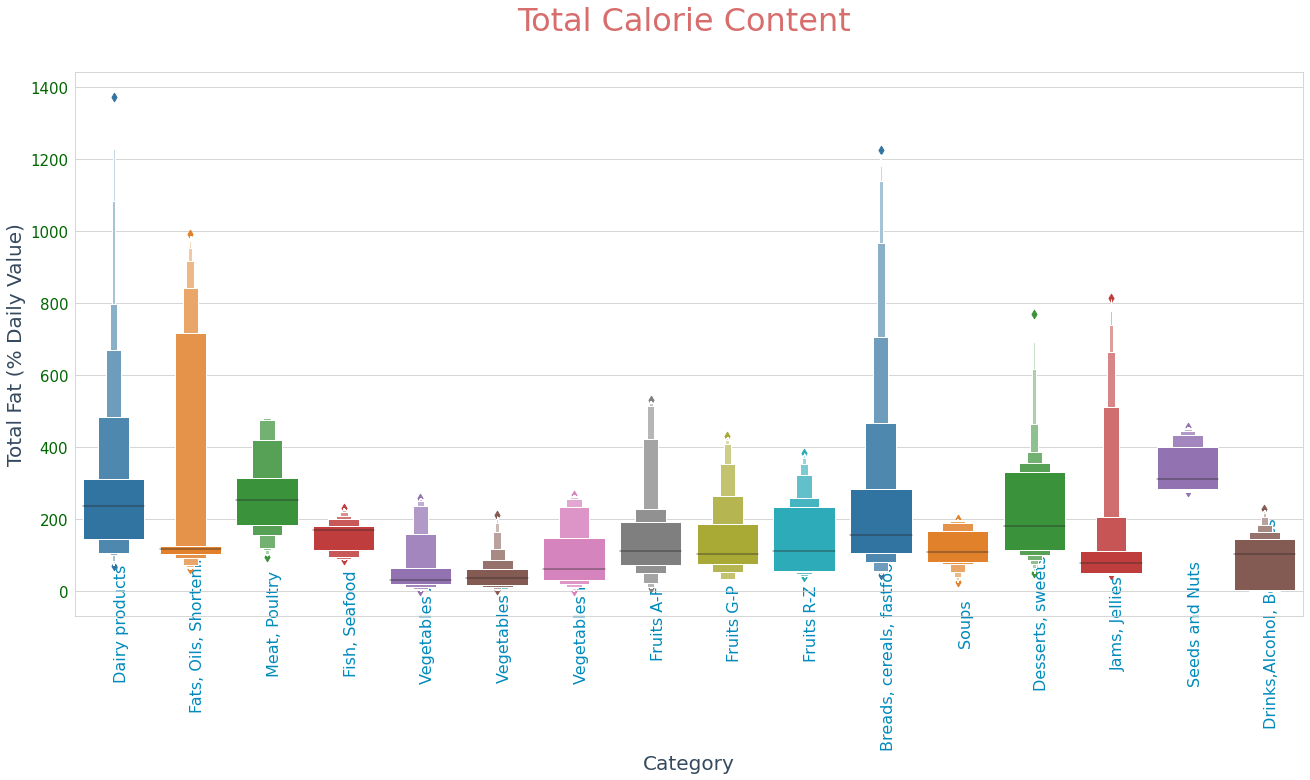

In [22]:
sns.set_style("whitegrid")
plt.figure(figsize=(22,10))
#plt.figure()

ax = sns.boxenplot(x="Category", y='Calories', data=nutrients, color='#eeeeee', palette="tab10")

# Add transparency to colors
for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .9))
    
#ax = sns.stripplot(x='Category', y='Cholesterol (% Daily Value)', data=menu, color="orange", jitter=0.5, size=5,alpha=0.15)
#
plt.title("Total Calorie Content \n", loc="center",size=32,color='#be0c0c',alpha=0.6)
plt.xlabel('Category',color='#34495E',fontsize=20) 
plt.ylabel('Total Fat (% Daily Value)',color='#34495E',fontsize=20)
plt.xticks(size=16,color='#008abc',rotation=90, wrap=True)  
plt.yticks(size=15,color='#006600')
#plt.text(2.5, 1, 'Courtesy: https://seaborn.pydata.org/examples/grouped_boxplot.html', fontsize=13,alpha=0.2)
#plt.ylim(0,200)
#plt.legend(loc="upper right",fontsize=14,ncol=5,title='Category',title_fontsize=22,framealpha=0.99)
plt.show()


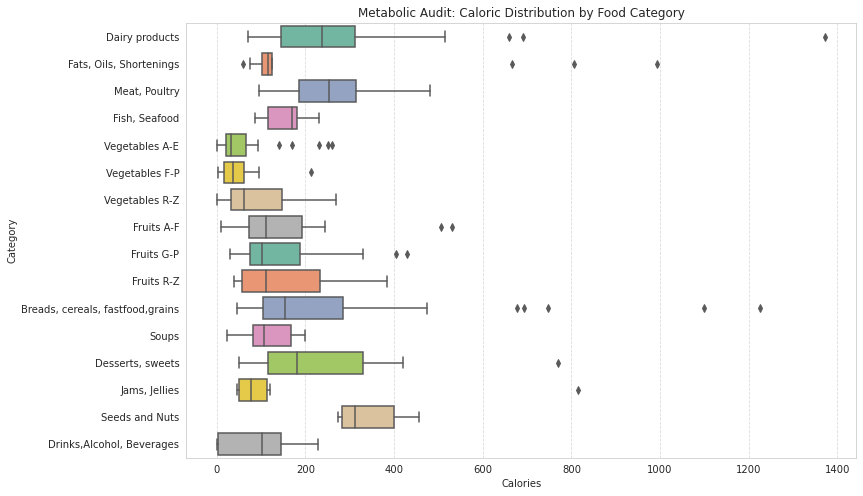

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a professional visualization of the audit
plt.figure(figsize=(12,8))
sns.boxplot(data=nutrients, x='Calories', y='Category', palette='Set2')
plt.title('Metabolic Audit: Caloric Distribution by Food Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

This notebook was an attempt to visualize data that is a part of every single person's life and analysing our basic needs in terms of nutrients. Upvote if you like it and share possible improvements in the comments.

# Key Findings

- Several high carbohydrate foods showed very low fiber content, which may indicate lower nutrient density.

- Certain processed food categories contained elevated sodium and saturated fat levels.

- Nutritional imbalance patterns appeared more frequently in dessert and snack related categories.

- Data cleaning was essential because some nutrition values contained formatting inconsistencies and missing values.

- Nutritional analysis can help support metabolic health awareness and food transparency efforts.

# Public Health Perspective

Understanding nutritional patterns in ultra processed foods may help support:

- preventative health awareness
- nutrition education initiatives
- healthier consumer decision making
- food transparency efforts
- metabolic wellness discussions

Data analysis can help transform nutrition information into clearer insights that support long term public health understanding.

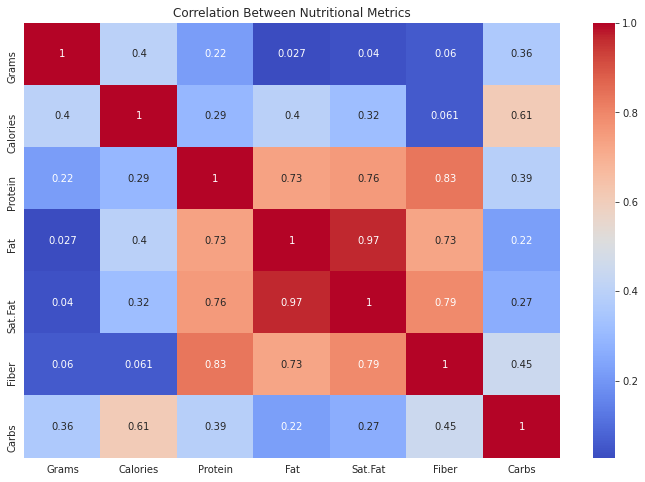

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
corr = nutrients.select_dtypes(include='number').corr()

# Create heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

# Title
plt.title('Correlation Between Nutritional Metrics')

# Show chart
plt.show()

### Correlation Heatmap Observation

This heatmap shows relationships between nutritional metrics in the dataset. Stronger correlations may help identify how nutrients cluster together across common foods, such as calorie density, fat content, carbohydrate levels, sodium, fiber, and protein.

This type of analysis helps move the notebook beyond individual food comparisons and into broader nutrition pattern recognition.

## 🔍 Project Overview: Ultra Processed Food Audit

### The Objective

As a Certified Nutritionist and Data Analyst, I created this audit to explore how common foods compare across key nutrition metrics such as calories, sugar, sodium, carbohydrates, fat, fiber, and protein.

The goal is to identify patterns that may help explain how ultra processed foods can affect metabolic health, energy balance, and long term wellness.

### The Methodology

This analysis uses Python and pandas to clean, organize, and explore nutrition data. The notebook focuses on identifying patterns in food categories, nutrient density, and potential metabolic risk factors.

# Future Improvements

Future analysis could include:

- predictive modeling for metabolic risk indicators
- food category clustering analysis
- sodium to calorie ratio comparisons
- glycemic load estimation
- nutrient density scoring
- additional visualization dashboards
- time series nutrition trend analysis